# ReGRID model analysis

### Power grid structure

Developed: 30 January, 2026

Note:
- This notebook depends on output files generated by the following notebooks:
  - model.py

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx
import os
import math
from shapely.geometry import Polygon
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [ ]:
# Case setting
TERM = '1y' # Analysis term: 1y=Yearly
STEP = 6 # Timestep(h)
VER = 'v8' # Model version
YEAR = 2050 # Target year
BOUNDARY = 'japan' # Spatial boundary
NETWORK = '1741' # TSN:Transmission, '1741':Municipality
PATHWAY = 'C1' # Socioeconomic and emission pathway: C1:1.5C, C7:below 4C
POTENTIAL_AVAILABILITY = 100 # Uniform availability of renewable energy(%)
POTENTIAL_CASE = 'base' # Renewable energy potential assumptions ('base':HPA, 'low':PA+OECM, 'mid':Enhanced, 'high':FullProtect)
COST_CASE = 'moderate' # Cost assumption

TECH_CASE = 'ccs-biomass'
if TECH_CASE == 'ccs-biomass':
    CCS_AVAILAVILITY = 2 # 0:Not available, 1:Unlimited, 2:Only domestic
    NUCLEAR_AVAILABILITY = 2 # 0:Not available, 1:Available, 2:No new installation
    BIOMASS_CAP = 0.1 # Availability of technical potential
else:
    CCS_AVAILAVILITY = 1 # 0:Not available, 1:Unlimited, 2:Only domestic
    NUCLEAR_AVAILABILITY = 1 # 0:Not available, 1:Available, 2:No new installation
    BIOMASS_CAP = 1 # Availability of technical potential

In [3]:
# Initialize a model
def get_model_name(ver=VER, year=YEAR, pathway=PATHWAY, term=TERM, step=STEP, boundary=BOUNDARY, network=NETWORK, nuclear=NUCLEAR_AVAILABILITY, potential=POTENTIAL_AVAILABILITY, potential_case=POTENTIAL_CASE, cost_case=COST_CASE, tech_case=TECH_CASE):
    return f"ReGRID2_{ver}_{year}_{pathway}_{term}_{step}_{boundary}_{network}_n{nuclear}_p{potential}_{potential_case}_{cost_case}_{tech_case}"

model_name = get_model_name()
print(model_name)

ReGRID2_v8_2050_C1_1y_6_japan_1741_n2_p100_base_moderate_ccs-biomass


In [ ]:
########### Input data ##########

# Region list
region_list = pd.read_csv('input/region.csv', index_col='code', dtype={'code':str, 'DSN':str, 'pref_code':str})
REGION = region_list.index.to_list() # All nodes
SUBSTATION = pd.read_csv('input/region_substation.csv', index_col=0, dtype={'region':str})['region'].to_list() # Substation nodes
NODE = [r for r in REGION if r not in SUBSTATION] # Terminal nodes
AREA = region_list['DSN'].copy() # Distribution area
REGION06 = pd.Series(data=[f"{r:>6}".replace(' ','_') for r in REGION], index=REGION) # Region list (6 digit code)
SPREGION = {}

# Technology list
RESOURCE = ['hydro','geoth','river','onwin','of-fx','of-fl','solar']
WASTE = ['waste','msw-c']
WOODY = ['woody','beccs']
FOSSIL = ['coalp','coalc','gas-p','gas-c','oil-p']
STORAGE = ['stpmp','stbat']
H2TECH = ['st-h2','el-h2','h2-el']
DACCS = ['daccs']
AUX = ['stpcs','h2cmp']
if NUCLEAR_AVAILABILITY != 0:
    THERMAL = FOSSIL + ['nuclr']
else:
    THERMAL = FOSSIL

# Technology dataset (Cost, Efficiency, etc.)
P = pd.read_csv(f'input/technology/technology_{PATHWAY}.csv', index_col=0)
P = P[(P['year'] == YEAR) & (P['scenario'] == COST_CASE)]

# Renewable energy temporal profiles
profile = {}
profile["solar"] = pd.read_csv('input/%sh/solar_2019.csv' % (STEP), index_col=0)
profile["onwin"] = pd.read_csv('input/%sh/onwind_2019.csv' % (STEP), index_col=0)
profile["of-fx"] = pd.read_csv('input/%sh/ofwind_2019_fixed.csv' % (STEP), index_col=0)
profile["of-fl"] = pd.read_csv('input/%sh/ofwind_2019_float.csv' % (STEP), index_col=0)
profile["river"] = pd.read_csv('input/%sh/river_2019.csv' % (STEP), index_col=0)
profile["geoth"] = pd.read_csv('input/%sh/geothermal_2019.csv' % (STEP), index_col=0)
profile["hydro"] = pd.read_csv('input/%sh/hydro_2019.csv' % (STEP), index_col=0)

# Annual capacity factor for renewables
CF_annual = {}
for res in profile.keys():
    CF_annual[res] = (profile[res] / STEP).mean()

# H2 demand
h2_demand = pd.read_csv('input/h2_demand.csv', index_col=0, dtype={'code':str})
SPREGION['h2'] = h2_demand.index.to_list()
SPREGION['h2'] = [r for r in SPREGION['h2'] if r in SUBSTATION]

In [6]:
# Data for analysis

# Optimal
optimal = pd.read_csv('output/%s/primal_%s.csv' % (model_name,model_name), index_col=0, dtype={'region':str, 'time':str})
optimal = optimal.replace('_', '', regex=True)
optimal = optimal.replace(' ', '', regex=True)

# Coordinate
city_coord = pd.read_csv('input/analysis/position.csv', index_col=0, dtype={'code':str})
offshore_float_coord = pd.read_csv('input/analysis/position_offshore_float.csv', index_col=0, dtype={'code':str})
offshore_fixed_coord = pd.read_csv('input/analysis/position_offshore_fixed.csv', index_col=0, dtype={'code':str})

# Technology list
BIOMASS = WASTE+WOODY
POWER_SOURCE = RESOURCE[::-1]+BIOMASS+THERMAL+['h2-el'] # All power sources

In [7]:
# Chart paramter
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 2.5
plt.rcParams['ytick.major.size'] = 2.5
plt.rcParams['font.size'] = 7
plt.rcParams['xtick.labelsize'] = 7
plt.rcParams['ytick.labelsize'] = 7
plt.rcParams['axes.linewidth'] = 0.5

MAX_WIDTH = 180 / 25.4 # inch in 180mm

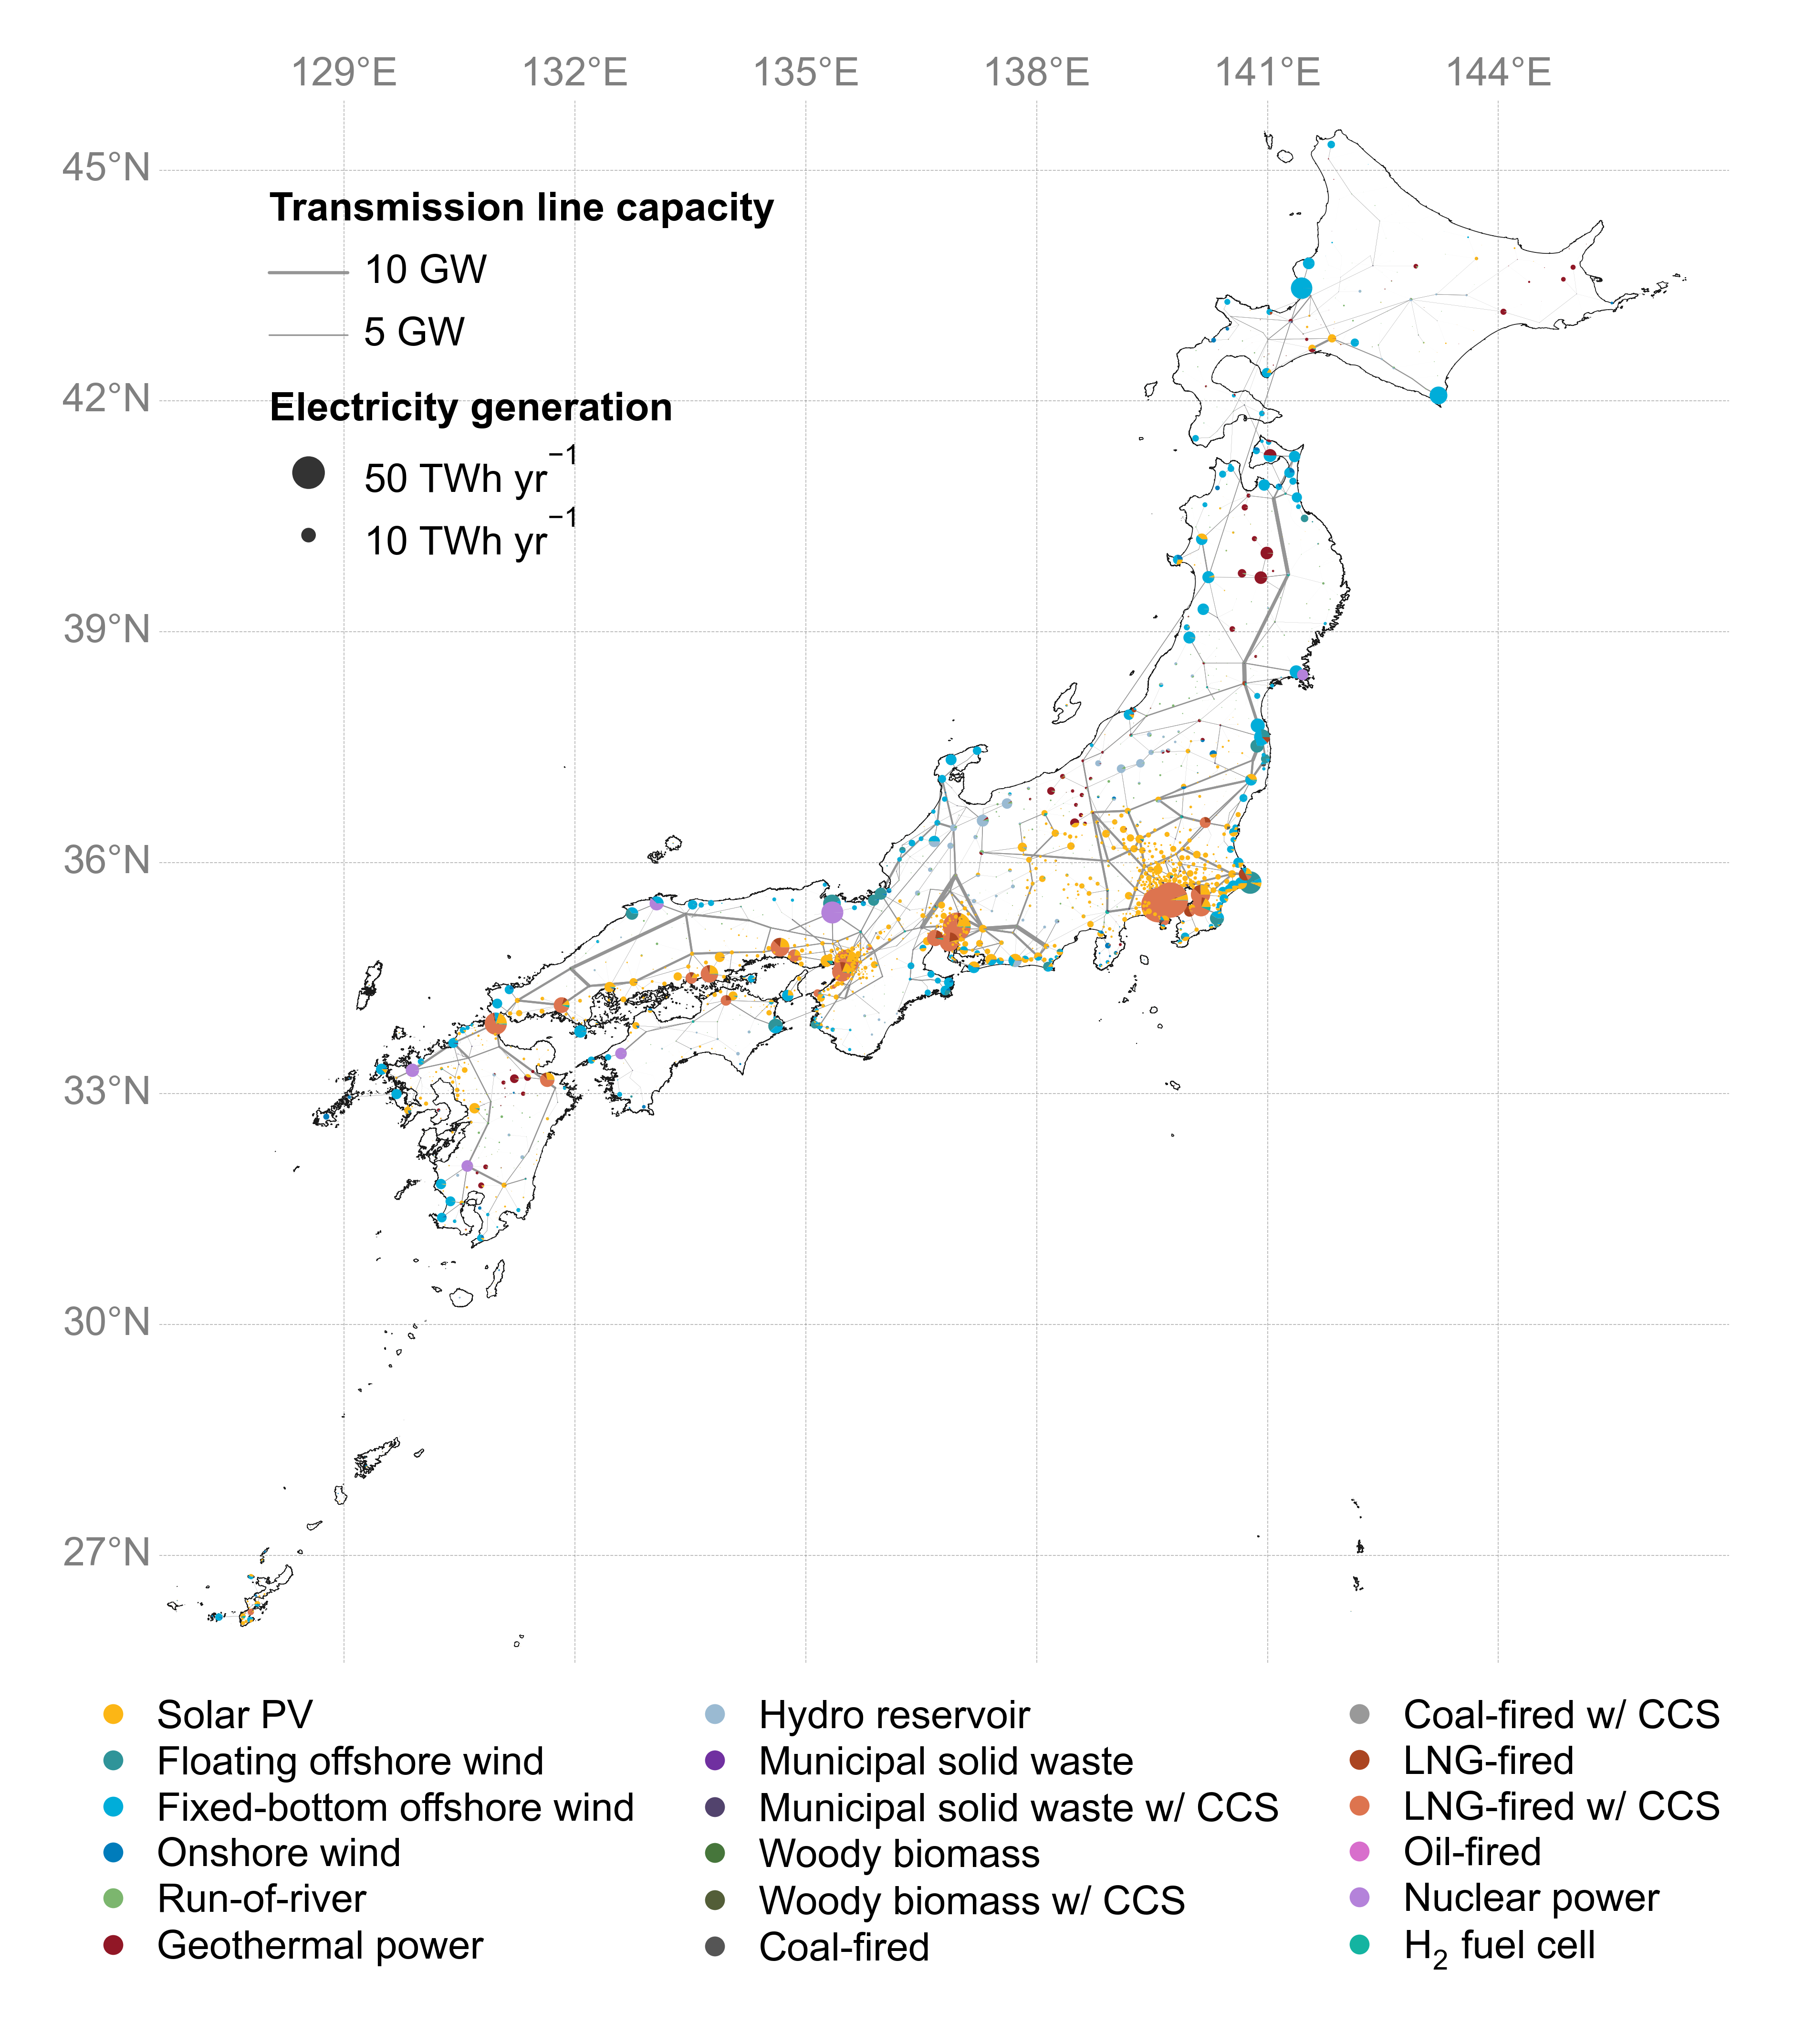

<Figure size 640x480 with 0 Axes>

In [10]:
########## Grid map ##########

# Data
grid = optimal[optimal.id == 'grd'].groupby(['region','general'], as_index=True).sum()['value']
export = optimal[optimal.id == 'exp'].groupby(['region','general'], as_index=True).sum()['value']
cap_region = optimal[optimal.id == 'cap'].groupby(['region','general']).sum()
gen_region = optimal[optimal.id == 'gen'].groupby(['region','general']).sum()

#####################################
#   Base map
#####################################

# Setup grid map
fig = plt.figure(figsize=(MAX_WIDTH*0.5, MAX_WIDTH*0.5), dpi=1200)
ax = plt.axes(projection=ccrs.PlateCarree())

# Geographical coverage [W,E,S,N]
area_coord = [126.6, 147.0, 25.6, 45.9]
map_width = area_coord[1]-area_coord[0]
map_height = area_coord[3]-area_coord[2]

# Municipal boundary
municipal_shapes = list(shpreader.Reader("input/analysis/shp/1741municipalities/1741municipalities.shp").geometries())
    
# National boundary
japan_shapes = list(shpreader.Reader("input/analysis/shp/Japan/Japan.shp").geometries())
ax.add_geometries(japan_shapes, ccrs.PlateCarree(), edgecolor=(0.1,0.1,0.1,1), facecolor=(0,0,0,0), linewidth = 0.1, zorder=2)

# Create position dictionary
pos_dict = {city: [city_coord['long'][city], city_coord['lat'][city]] for city in city_coord.index}

# Size adjustment parameters
flow_adjust = 0.002 # Adjust width of power flow
line_adjust = 0.00004 # Adjust width line capacity
node_adjust = 0.03 # Adjust Pi chart size
node_pie_adjust = 0.3 # Adjust networkx nodes
legend_node_size = 5 # Adjust legend circle size
title_size = 5 # Annotation title font size
annot_size = 5 # Annotation font size

# color
flow_color = '#FA8000'
line_color = "#959595"
pie_color = '#555555'


#####################################
#   Transmission capacity network
#####################################

Grid = nx.DiGraph()
Grid.add_nodes_from(REGION)
Grid.add_edges_from(grid.index)
grid_capacity = (grid.loc[list(Grid.edges())] * line_adjust).to_list()
nx.draw_networkx(Grid, pos=pos_dict, with_labels=False, arrowstyle ='-', node_size=0, width=grid_capacity, edge_color=line_color)


#############################
#   Generation (pie charts)
#############################

# Discarding islands out of boundary
discard = ['472077','473758','473821','472140','473812'] #石垣市,多良間村,与那国町,宮古島市,竹富町

# Draw pie charts
for city in sorted(REGION):
    if city in discard:
        continue
    else:
        if city in SUBSTATION:
            pie_mix = [max(round(cap_region.loc[(city,res)].value * profile[res][city].sum()), 0.1) for res in RESOURCE[::-1]] + [(max(round(gen_region.loc[(city,f)].value), 0.1) if ((city,f) in gen_region.index) else 0.1) for f in BIOMASS+THERMAL] + [max(gen_region.loc[(city,'h2-el')].value, 0.1) if city in SPREGION['h2'] else 0]
            pie_color = [P['color'][res] for res in POWER_SOURCE]
        else:
            pie_mix = [max(round(cap_region.loc[(city,res)].value * profile[res][city].sum()), 0.1) for res in RESOURCE]
            pie_color = [P['color'][res] for res in RESOURCE]
        pie_size = (sum(pie_mix)/1000000)**0.5*node_adjust
        pie_chart, pie_t = ax.pie(pie_mix, center=(city_coord['long'][city],city_coord['lat'][city]), colors=pie_color, radius=pie_size)
        [p.set_zorder(10) for p in pie_chart]


#####################################
#   Legend
#####################################

legend_handles = [Line2D( [0], [0], marker='o', color='none', markeredgecolor='none', markerfacecolor=c, markersize=2.5) for c in [P['color'][res] for res in POWER_SOURCE]]
ax.legend(legend_handles, [P['name'][res] for res in POWER_SOURCE], loc="lower center", bbox_to_anchor=(0.47, -0.22), ncol=3, frameon=False, fontsize=5, labelspacing=0.25, columnspacing=1, handletextpad=0.1)

# Legend values
line = [10,5] #GW
gen = [50,10] #TWh
n_legend_nodes = len(line)*2
legend_line = [l * 1000 * line_adjust for l in line]
legend_color = ['#fff']*n_legend_nodes
legend_size = [0]*n_legend_nodes
legend_width = legend_line
legend_edge_color = [line_color for i in line]
legend_x = area_coord[0] + map_width * 0.12
legend_y = area_coord[2] + map_height * 0.93
legend_interval = map_height*0.04*-1
legend_length = map_width * 0.05
annot_margin = legend_length*0.2
pos_dict_legend= {}


# Scale legend (top-left)
def edge_annotate(title, x, y, s, p0, p1):
    ax.annotate(title, xy=(x+annot_margin, y), size=s, verticalalignment='center')
    pos_dict_legend.setdefault(p0,[x-legend_length, y]) #Left
    pos_dict_legend.setdefault(p1,[x, y]) #Right

def pie_annotate(title, x, y, s, rad):
    ax.annotate(title, xy=(x+annot_margin, y), size=s, verticalalignment='center')
    ax.pie([1], center=(x-legend_length/2, y), colors=["#333"], radius=rad**0.5*node_adjust)

ax.annotate("Transmission line capacity", xy=(legend_x-legend_length,legend_y), size=title_size, verticalalignment='center', fontweight='bold')
legend_y = legend_y + legend_interval
edge_annotate(f"{line[0]} GW", legend_x, legend_y, annot_size, 30, 31)
legend_y = legend_y + legend_interval
edge_annotate(f"{line[1]} GW", legend_x, legend_y, annot_size, 40, 41)
legend_y = legend_y + legend_interval*1.2

ax.annotate("Electricity generation", xy=(legend_x-legend_length,legend_y), size=title_size, verticalalignment='center', fontweight='bold')
legend_y = legend_y + legend_interval
pie_annotate(f"{gen[0]}"+r" TWh yr$^{-1}$", legend_x, legend_y, annot_size, gen[0])
legend_y = legend_y + legend_interval
pie_annotate(f"{gen[1]}"+r" TWh yr$^{-1}$", legend_x, legend_y, annot_size, gen[1])
legend_y = legend_y + legend_interval

# Draw legend
G_legend = nx.DiGraph()
G_legend.add_nodes_from([30, 31, 40, 41])
G_legend.add_edges_from([(30, 31), (40, 41)]) # line[0], line[1]
nx.draw_networkx(G_legend, pos=pos_dict_legend, with_labels=False, arrowstyle ='-', node_size=legend_size, node_color = legend_color, width=legend_width, edge_color = legend_edge_color)


#############################
#   Output
#############################

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.1, color='gray', alpha=0.6, linestyle='--')
gl.top_labels = True
gl.right_labels = False
gl.bottom_labels = False
gl.left_labels = True
gl.xlabel_style = {'fontsize': 5, 'color': "gray"}
gl.ylabel_style = {'fontsize': 5, 'color': "gray"}
gl.xformatter = LONGITUDE_FORMATTER #°E
gl.yformatter = LATITUDE_FORMATTER #°N
gl.xpadding = 1
gl.ypadding = 1

# Draw
ax.set_extent(area_coord, crs=ccrs.PlateCarree())
plt.axis('off')
plt.savefig(f"output/{model_name}/map_grid_{model_name}_{BOUNDARY}.png", bbox_inches='tight', pad_inches=0, transparent=False, dpi=1200)
plt.savefig(f"output/{model_name}/map_grid_{model_name}_{BOUNDARY}.pdf", bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()
plt.clf()

In [11]:
########## Renewable energy landscape ##########


# Land requirements
cap = optimal[optimal.id == 'cap'].groupby(['general','region']).sum()['value']
land_use = pd.DataFrame()
VRE = ['solar','onwin','of-fx','of-fl']
for res in VRE:
    land_use[res] = cap.xs(res, level='general') * P['land'][res] #km^2

# Map extent [W, E, S, N]
area_cood = [126.6, 147.0, 25.6, 45.7]

# Generate square polygon
def create_square(center, size, quad):
    x, y = center
    length = math.sqrt(size) / 110 # km -> degree
    
    if quad == 'center':
        half = length/2
        coordinates = [
        (x - half, y + half), #Left top
        (x - half, y - half), #Left bottom
        (x + half, y - half), #Right bottom
        (x + half, y + half), #Right top
        (x - half, y + half) #Left top
        ]
    else:
        locx = 1
        locy = 1
        if quad == 2:
            locx = -1
        elif quad == 3:
            locx = -1
            locy = -1
        elif quad == 4:
            locx = 1
        coordinates = [
            (x, y),
            (x, y + length * locy),
            (x + length * locx, y + length * locy),
            (x + length * locx, y),
            (x, y)
        ]
    return Polygon(coordinates)

land_polygon = {}
for n,res in enumerate(['solar','onwin']):
    land_polygon[res] = [create_square((city_coord['long'][reg], city_coord['lat'][reg]), land_use[res][reg], n+1) for reg in REGION]
res = 'of-fx'
land_polygon[res] = [create_square((offshore_fixed_coord['long'][reg], offshore_fixed_coord['lat'][reg]), land_use[res][reg], 'center') for reg in REGION]
res = 'of-fl'
land_polygon[res] = [create_square((offshore_float_coord['long'][reg], offshore_float_coord['lat'][reg]), land_use[res][reg], 'center') for reg in REGION]


# Draw map
fig = plt.figure(figsize=(MAX_WIDTH*0.5, MAX_WIDTH*0.5), dpi=3000)
ax = plt.axes(projection=ccrs.PlateCarree())

# Municipal border
municipal_shapes = list(shpreader.Reader("input/analysis/shp/1741municipalities/1741municipalities.shp").geometries())
ax.add_geometries(municipal_shapes, ccrs.PlateCarree(), edgecolor=(0.8,0.8,0.8,1), facecolor=(1,1,1,0), linewidth = 0.01, zorder=1)

# National border
japan_shapes = list(shpreader.Reader("input/analysis/shp/Japan/Japan.shp").geometries())
ax.add_geometries(japan_shapes, ccrs.PlateCarree(), edgecolor=(0.1,0.1,0.1,1), facecolor=(0,0,0,0), linewidth = 0.05, zorder=2)

# Square polygon
for res in VRE:
    ax.add_geometries(land_polygon[res], ccrs.PlateCarree(), edgecolor=(0,0,0,0), facecolor=P['color'][res], linewidth = 0.2)

# Map extent
ax.set_extent(area_cood, crs=ccrs.PlateCarree())

# Legend
legend_length = (area_cood[1]-area_cood[0])*0.05 # 5% of width
interval = (area_cood[3]-area_cood[2])*0.04*-1 # 4% of height
margin_e = (area_cood[1]-area_cood[0])*0.92 # 95% from right
margin_s = (area_cood[3]-area_cood[2])*0.90 # 95% from bottom
annot_size = 5
annot_margin = legend_length*0.2
# Size
land_legend = [500, 300, 100]
for n,land_area in enumerate(land_legend):
    land_size = [create_square((area_cood[1]-margin_e-legend_length/2, area_cood[2]+margin_s+interval*n), land_area, 'center')]
    ax.add_geometries(land_size, ccrs.PlateCarree(), edgecolor=(0,0,0,0), facecolor='#333', linewidth = 0.2)
    ax.annotate("%d km²" % land_area, xy=(area_cood[1]-margin_e,area_cood[2]+margin_s+interval*n), size=annot_size, verticalalignment='center')
# Color
for n,res in enumerate(VRE):
    land_color = [create_square((area_cood[1]-margin_e-legend_length/2, area_cood[2]+margin_s+interval*(n+len(land_legend)+1)), land_legend[0], 'center')]
    ax.add_geometries(land_color, ccrs.PlateCarree(), edgecolor=(0,0,0,0), facecolor=P['color'][res], linewidth = 0.2)
    ax.annotate(P['name'][res], xy=(area_cood[1]-margin_e,area_cood[2]+margin_s+interval*(n+len(land_legend)+1)), size=annot_size, verticalalignment='center')

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.1, color='gray', alpha=0.6, linestyle='--')
gl.top_labels = True
gl.right_labels = False
gl.bottom_labels = False
gl.left_labels = True
gl.xlabel_style = {'fontsize': 5, 'color': "gray"}
gl.ylabel_style = {'fontsize': 5, 'color': "gray"}
gl.xformatter = LONGITUDE_FORMATTER #°E
gl.yformatter = LATITUDE_FORMATTER #°N
gl.xpadding = 1
gl.ypadding = 1

plt.axis('off')
plt.savefig(f"output/{model_name}/map_land_{model_name}_{BOUNDARY}.png", bbox_inches='tight', pad_inches=0, transparent=False, dpi=1200)
plt.savefig(f"output/{model_name}/map_land_{model_name}_{BOUNDARY}.pdf", bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>